## Table of contents

1. [**Inspecting Data**](#andmetesse_sissevaatamine)
2. [**Results BERT MLM-to-LLM-to-morphology model**](#tulemused_bert_mlm_to_llm_to_morph)

[end](#end)


### Imports


In [ ]:
print("Test")

Test


In [ ]:
import os
import evaluate
import re
import random
import math
import pandas as pd
import numpy as np
import estnltk, estnltk.converters, estnltk.taggers
import sklearn
import sklearn.metrics

from typing import Any, Tuple, Optional

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from tqdm import tqdm
from scripts.model.bert_morph_tagger import BertMorphTagger
from scripts.notebooks.NotebookFunctions import (
    _extract_prediction_from_layer,
    annotate_sentences_with_model,
    display_metrics_and_classification_report,
    plot_confusion_matrices,
    plot_true_vs_pred_by_inflection,
    display_examples,
    create_lenient_labels_and_split_counts_and_cases,
)

from scripts.config import (
    SEED,
    ROOT,
    DATA_DIR,
    ENC2017_ROOT,
    UD_ET_EDT_ROOT,
    HOMONYMS_ROOT,
    ENC2017_DIRS,
    UD_ET_EDT_DIRS,
    HOMONYMS_DIRS,
    OUTPUT_DIR,
    PLOTS_DIR,
    HOMONYMS_PLOTS_DIR,
    MODEL_DIR,
)

<a id='andmetesse_sissevaatamine'></a>


### Inspecting Data


In [ ]:
overall_df = pd.read_parquet(
    "../data/homonymous_word_forms/processed/homonyms_overall_updated_sentences.parquet"
)

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]",[sg n],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]",[sg g],infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


In [ ]:
import numpy as np

# Convert list/array inflection types to tuples for consistent grouping
overall_df["label"] = overall_df["label"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x
)

display(
    overall_df.groupby(["inflection_type", "label"])
    .size()
    .reset_index()
    .sort_values(by="inflection_type")
)

,inflection_type,label,0
0,1,"(sg g,)",1232
1,1,"(sg n,)",764
2,16,"(sg g,)",1080
3,16,"(sg n,)",890
4,17,"(sg g,)",524
5,17,"(sg n,)",791
6,17,"(sg p,)",609
7,19,"(adt,)",94
8,19,"(sg g,)",1621
9,19,"(sg p,)",281


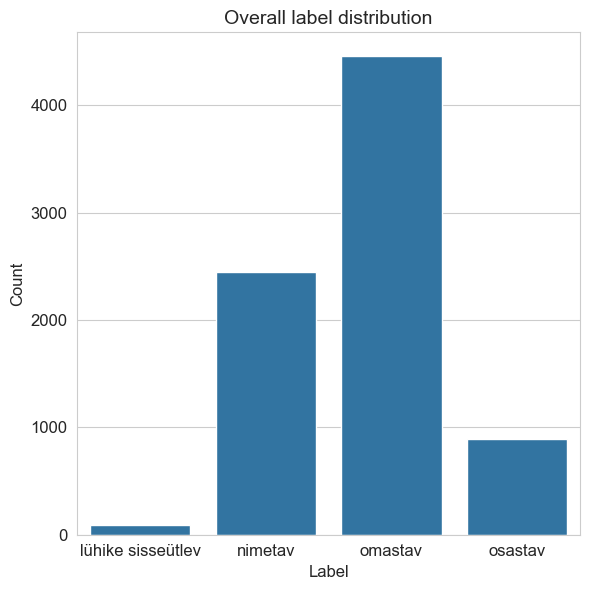

INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:category.py:224: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Admin\AppData\Local\Temp\ipykernel_32032\3500709682.py:38: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.countplot(


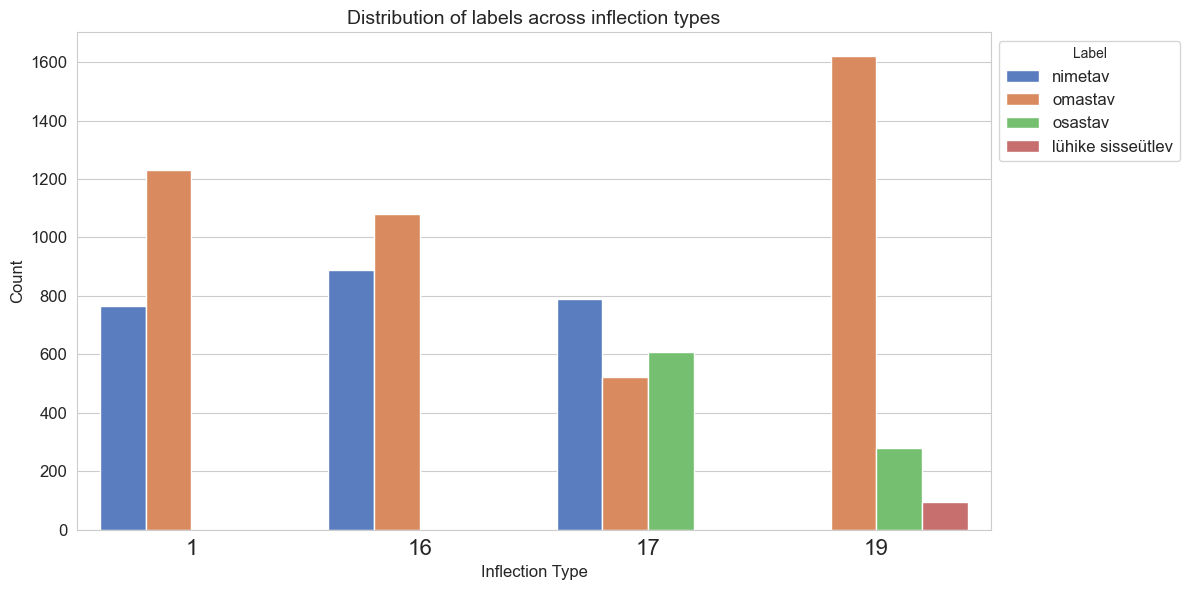

In [ ]:
overall_df["label_str"] = overall_df["label"].apply(lambda x: x[0])

# Rename the labels for better readability in plots
label_mapping = {
    "sg n": "nimetav",
    "sg g": "omastav",
    "sg p": "osastav",
    "adt": "lühike sisseütlev",
}
overall_df["label_str"] = (
    overall_df["label_str"].map(label_mapping).fillna(overall_df["label_str"])
)

# Plot label distribution
sns.set_style("whitegrid")
plt.figure(figsize=(6, 6))
sns.countplot(
    data=overall_df,
    x="label_str",
    order=sorted(overall_df["label_str"].dropna().unique()),
)
plt.title("Overall label distribution", fontsize=14)
plt.xlabel("Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "overall_label_distribution.png"),
    dpi=300,
)
plt.show()

# Plot label distribution across inflection types
sns.set_style("whitegrid")
palette = sns.color_palette("muted")
plt.figure(figsize=(12, 6))
sns.countplot(
    data=overall_df,
    x="inflection_type",
    hue="label_str",
    palette=palette,
    order=sorted(overall_df["inflection_type"].dropna().unique()),
)
plt.title("Distribution of labels across inflection types", fontsize=14)
plt.xlabel("Inflection Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=12)
plt.legend(title="Label", bbox_to_anchor=(1, 1), loc="upper left", fontsize=12)
plt.tight_layout()
plt.savefig(
    str(HOMONYMS_PLOTS_DIR / "label_distribution_by_inflection_type.png"),
    dpi=300,
)
plt.show()

In [ ]:
overall_df.head()

,num,inflection_type,sentence,word,word_span,label,source
0,1,1,"Edinburghi agulite mehe Irvine Welshi ja Glasgow tööliskirjaniku, Bookeri võitja James Kelmani puhul võib tõlketõrke tekitada keelekasutus - inglise inglise keelele demonstratiivselt vastanduv proletaarne Scots.",võitja,"[74, 80]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
1,1,1,"Normi-aktiveerimise teooria (Schwartz, 1970) on algselt mõeldud moraalse otsustamisprotsessi analüüsimiseks abistava käitumise näitel.",teooria,"[20, 27]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
2,1,1,"""Ehk oleks mõttekas ka mõni selleteemaline hoiatav kampaania korraldada,"" lisab punase autoga preili.",kampaania,"[51, 60]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
3,1,1,"""Minu otsus oli õige ning teeksin kõik sama moodi, kui saaksin uuesti teha,"" kommenteerib kolm aastat tagasi eriliste teenete eest Eesti passi saanud Primakov.",õige,"[16, 20]","(sg n,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json
4,1,1,"Itaalia president ütles Venemaa riigipea auks korraldatud suurejoonelisel banketil, et kahe riigi ühisavaldus Iraagi kohta oli kahe riigipea ""suur tarkuseavaldus"".",Itaalia,"[0, 7]","(sg g,)",infl_type_01_1000_v1_project-1-at-2024-11-23-00-10-742338cd.json


<a id='tulemused_bert_mlm_to_llm_to_morph'></a>


### BERT MLM-to-LLM-to-morphology model predictions for the homonym dataset


In [ ]:
max_rows = 200
bert_llm_results_df = pd.read_json(
    HOMONYMS_DIRS["processed"] / f"genai_annotations_bert_mlm_{max_rows}.json"
)
# Rename columns for consistency
bert_llm_results_df = bert_llm_results_df.rename(columns={"label": "true_label"})
display(bert_llm_results_df.head())

,id,candidates,candidate_details,predictions,pred_label,source_sentence,target_word,word_span,true_label
0,160,"[juhtumi, õnnetuse, sündmuse, asja, teo]","[{'token': 'juhtumi', 'score': 0.103648349642753, 'resolved_form': ['sg g'], 'normalised_score': 0.47063821786965804}, {'token': 'sündmuse', 'score': 0.060792475938797004, 'resolved_form': ['sg g'], 'normalised_score': 0.27604166042522005}, {'token': 'asja', 'score': 0.03698594123125, 'resolved_form': ['sg g'], 'normalised_score': 0.167942832927921}, {'token': 'õnnetuse', 'score': 0.017669614404439, 'resolved_form': ['sg g'], 'normalised_score': 0.08023278578397501}, {'token': 'teo', 'score': 0.0011329705594100002, 'resolved_form': ['sg g'], 'normalised_score': 0.005144502993223001}]",{'sg g': 0.9999999999999991},sg g,Harju politseiprefektuur algatas juhtunu uurimiseks kriminaalasja.,juhtunu,"[33, 40]",sg g
1,4623,"[Kanada, Prantsusmaa, Suurbritannia, Rootsi, Austraalia]","[{'token': 'Kanada', 'score': 2.303554083482595e-06, 'resolved_form': ['sg g'], 'normalised_score': 1.0}]",{'sg g': 1.0},sg g,"Väitekirja struktuur Tulenevalt väitekirja ülesehitusest õpik-monograafiana on töö eesmärkide saavutamiseks 1) uuritud maksukorralduse ja tarbimismaksude teoreetilisi aluseid ; 2) käsitletud käibemaksu rakendamise ajalugu ning põhjusi, mis mõjutasid selle rakendamist Euroopa Liidus või rakendamise edasilükkamist Ameerika Ühendriikides ; 3) analüüsitud käibemaksu puhul kasutatavat terminoloogiat ja käibemaksu rakendamise praktilisi probleeme ning selgitatud nende võimalikke lehendusi autori poolt väljatöötatud praktiliste näidetega ; 4) analüüsitud toiduainete käibemaksumäära alandamise mõju leibkondade elujärjele võrrelduna tulumaksuvaba miinimumi tõstmisega kaasneva mõjuga.",Ameerika,"[314, 322]",sg g
2,4502,"[ruupia, krooni, margi, euro, dollari]","[{'token': 'krooni', 'score': 0.04748411104083, 'resolved_form': ['sg g'], 'normalised_score': 0.7586655389233481}, {'token': 'dollari', 'score': 0.008771171793341, 'resolved_form': ['sg g'], 'normalised_score': 0.14013920930019802}, {'token': 'euro', 'score': 0.006333708763122001, 'resolved_form': ['sg g'], 'normalised_score': 0.10119525177645301}]",{'sg g': 1.0},sg g,"Teisipäeval, 10. veebruaril teatas Indoneesia esindajatekoja asespiiker Abdul Gafur, et riigi parlament toetab valitsuse ettepanekut rakendada Indoneesia valuuta, ruupia stabiliseerimiseks valuutakomitee põhimõtet.",ruupia,"[163, 169]",sg g
3,200,"[aasta, päeva, päev]","[{'token': 'aasta', 'score': 0.9385154843330381, 'resolved_form': ['sg g'], 'normalised_score': 0.9999855939316481}, {'token': 'aasta', 'score': 1.103962040360784e-05, 'resolved_form': ['sg g'], 'normalised_score': 1.176268431407606e-05}, {'token': 'päeva', 'score': 2.480892590028816e-06, 'resolved_form': ['sg g'], 'normalised_score': 2.643384037380722e-06}]",{'sg g': 0.9999999999999991},sg g,"26. veebruar, esmaspäev Kell 18.15-18.35 kadus Tihniku 5 Maksimarketi eest helebeezh VAZ 21063 numbriga 903 ABL, 1985. aasta väljalase.",aasta,"[119, 124]",sg g
4,833,[Euroopa],"[{'token': 'Euroopa', 'score': 0.9961523413658141, 'resolved_form': ['sg g'], 'normalised_score': 0.9999355446391751}, {'token': 'Euroopa', 'score': 6.421149737434462e-05, 'resolved_form': ['sg g'], 'normalised_score': 6.445536082470901e-05}]",{'sg g': 1.0},sg g,"Valitsuse pöördumine : ""Ühinemine Euroopa Liidu ja NATO-ga oli iseseisvuse taastanud Eesti jaoks kõige olulisem välispoliitiline eesmärk.",Euroopa,"[34, 41]",sg g


In [ ]:
# Load original results dataframe
results_df_v2 = pd.read_csv(
    HOMONYMS_DIRS["processed"] / "homonyms_annotations_Bert_morph_V2.csv",
    index_col=False,
)

# Filter out only the rows in the original results that correspond to the sentences in the LLM sample
llm_sentences = bert_llm_results_df["source_sentence"].unique()
results_df_v2_llm_subset = results_df_v2[results_df_v2["sentence"].isin(llm_sentences)]
print(
    len(results_df_v2_llm_subset),
    "rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset",
)
print(len(bert_llm_results_df), "rows in LLM MLM results for homonyms subset")

# Add inflection type column from subset of original results to LLM results
# Create a new column in the LLM results dataframes to hold the inflection type
bert_llm_results_df["inflection_type"] = results_df_v2_llm_subset[
    "inflection_type"
].values

200 rows in BertMorphTaggerV2 results corresponding to LLM homonyms subset
200 rows in LLM MLM results for homonyms subset


In [ ]:
print(f"BERT MLM-to-LLM-to-morph results on homonyms subset ({max_rows}):")
display_metrics_and_classification_report(
    results_df=bert_llm_results_df,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

display_metrics_and_classification_report(
    results_df=bert_llm_results_df,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

print(f"Bert Morph Tagger V2 results on homonyms subset ({max_rows}):")
display_metrics_and_classification_report(
    results_df=results_df_v2_llm_subset,
    pred_col="pred_label",
    true_col="true_label",
    show_metrics=True,
    show_classification_report=False,
)

display_metrics_and_classification_report(
    results_df=results_df_v2_llm_subset,
    pred_col="pred_label",
    true_col="true_label",
    group_col="inflection_type",
    show_metrics=True,
    show_classification_report=False,
)

BERT MLM-to-LLM-to-morph results on homonyms subset (200):
Overall results
Accuracy:  74.50%
Precision: 84.91%
Recall:    74.50%
F1-score:  78.05%
inflection_type=1
Accuracy:  77.50%
Precision: 94.50%
Recall:    77.50%
F1-score:  84.88%
inflection_type=16
Accuracy:  65.00%
Precision: 92.50%
Recall:    65.00%
F1-score:  73.53%
inflection_type=17
Accuracy:  68.33%
Precision: 78.97%
Recall:    68.33%
F1-score:  70.08%
inflection_type=19
Accuracy:  85.00%
Precision: 95.12%
Recall:    85.00%
F1-score:  88.81%
Bert Morph Tagger V2 results on homonyms subset (200):
Overall results
Accuracy:  93.50%
Precision: 95.17%
Recall:    93.50%
F1-score:  94.12%
inflection_type=1
Accuracy:  97.50%
Precision: 97.62%
Recall:    97.50%
F1-score:  97.50%
inflection_type=16
Accuracy:  97.50%
Precision: 97.62%
Recall:    97.50%
F1-score:  97.50%
inflection_type=17
Accuracy:  90.00%
Precision: 95.22%
Recall:    90.00%
F1-score:  92.14%
inflection_type=19
Accuracy:  91.67%
Precision: 92.78%
Recall:    91.67%
F1

BERT MLM-to-LLM-to-morph results on homonyms subset (200):


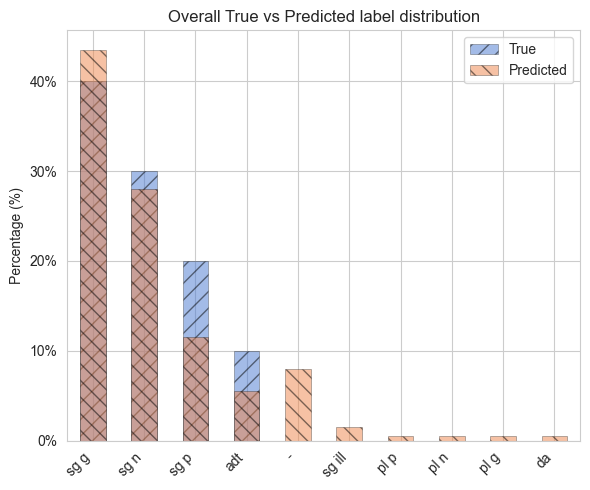

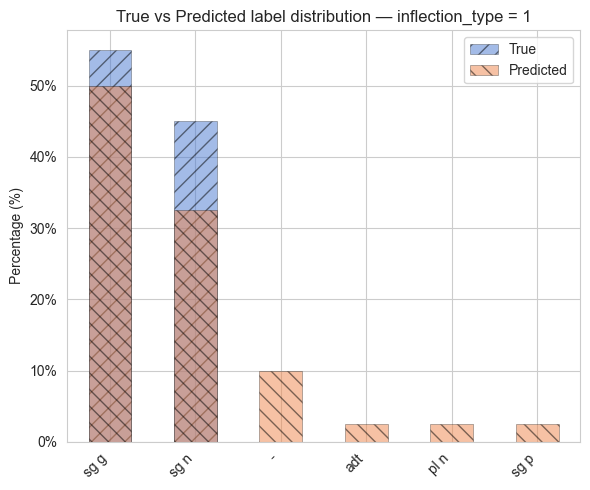

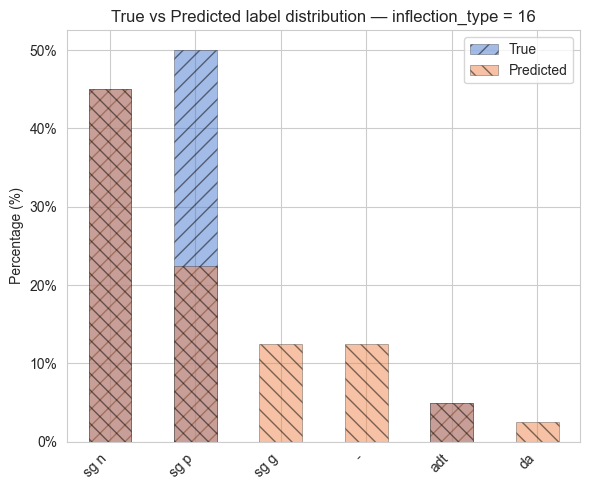

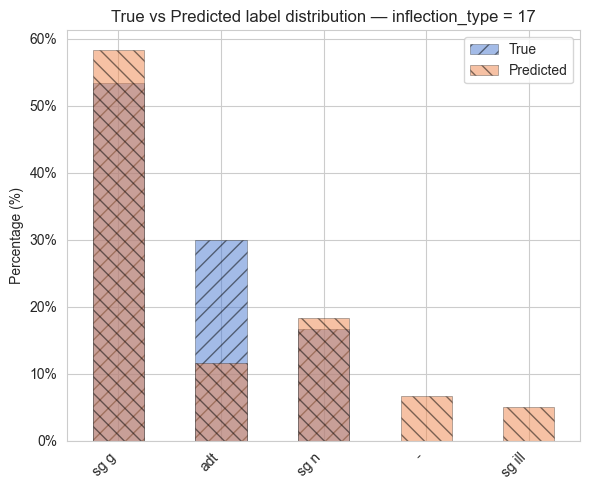

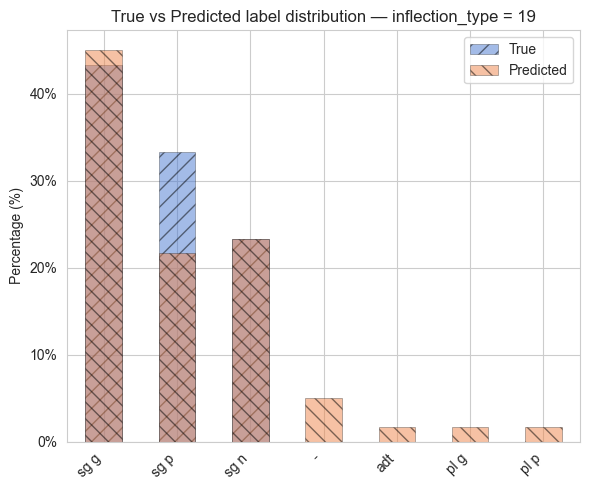

Bert Morph Tagger V2 results on homonyms subset (200):


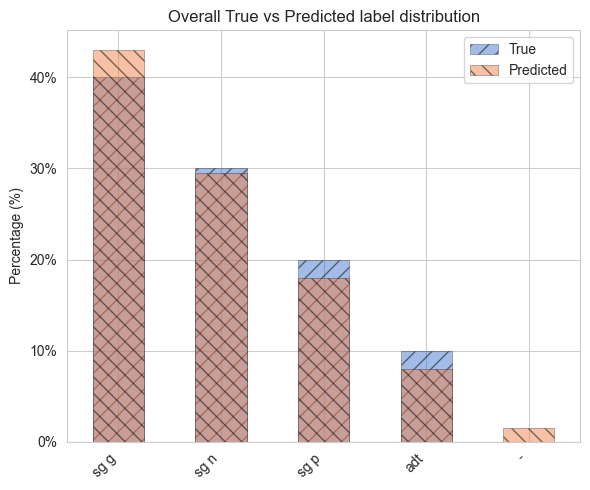

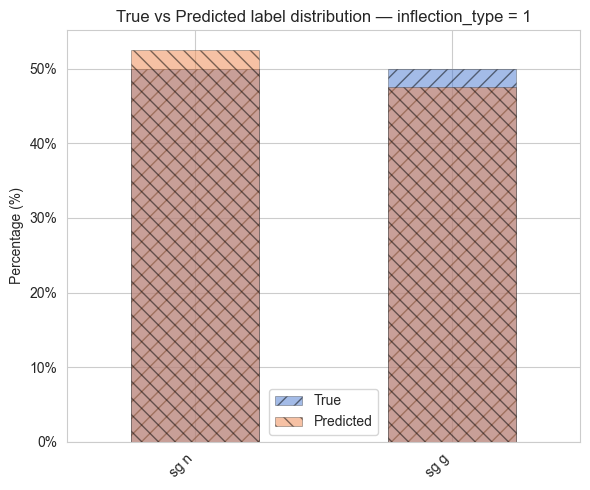

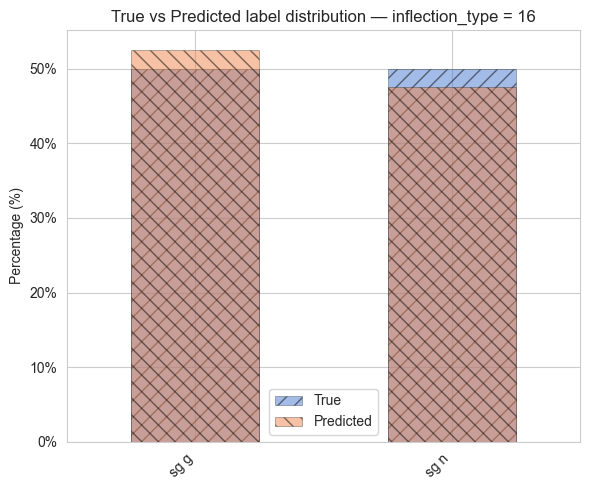

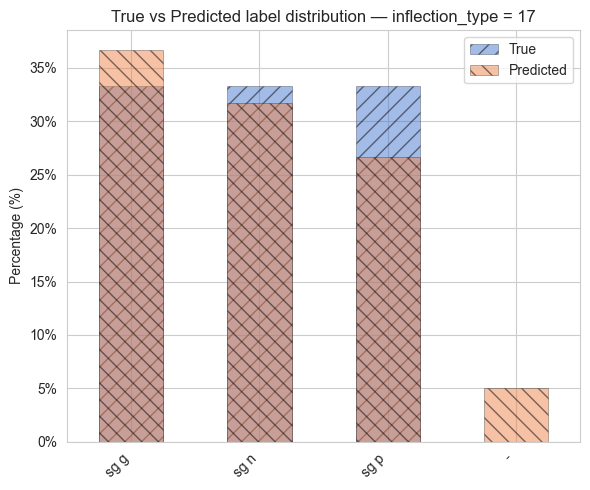

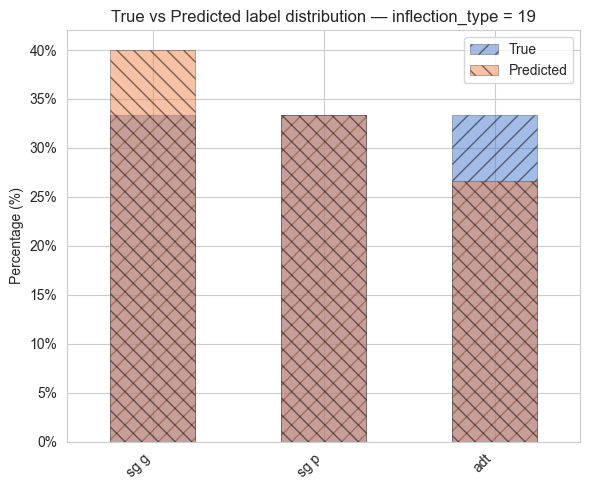

In [ ]:
print(f"BERT MLM-to-LLM-to-morph results on homonyms subset ({max_rows}):")
plot_true_vs_pred_by_inflection(
    bert_llm_results_df,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    # save_dir=str(OUTPUT_DIR / "plots" / "homonyms" / "MLM_LLM"),
    # save_prefix="LLM_true_vs_pred_homonym_full",
)
print(f"Bert Morph Tagger V2 results on homonyms subset ({max_rows}):")
plot_true_vs_pred_by_inflection(
    results_df_v2_llm_subset,
    figsize=(6, 5),
    pred_width_ratio=1.0,
    width=0.5,
    hatch_true="//",
    hatch_pred="\\\\",
    alpha=0.5,
    plot_per_inflection=True,
    plot_overall=True,
    # save_dir=str(OUTPUT_DIR / "plots" / "homonyms" / "MLM_LLM"),
    # save_prefix="BertMorphTagger_true_vs_pred_homonym_full",
)

BERT MLM-to-LLM-to-morph confusion matrix for homonyms subset (200):


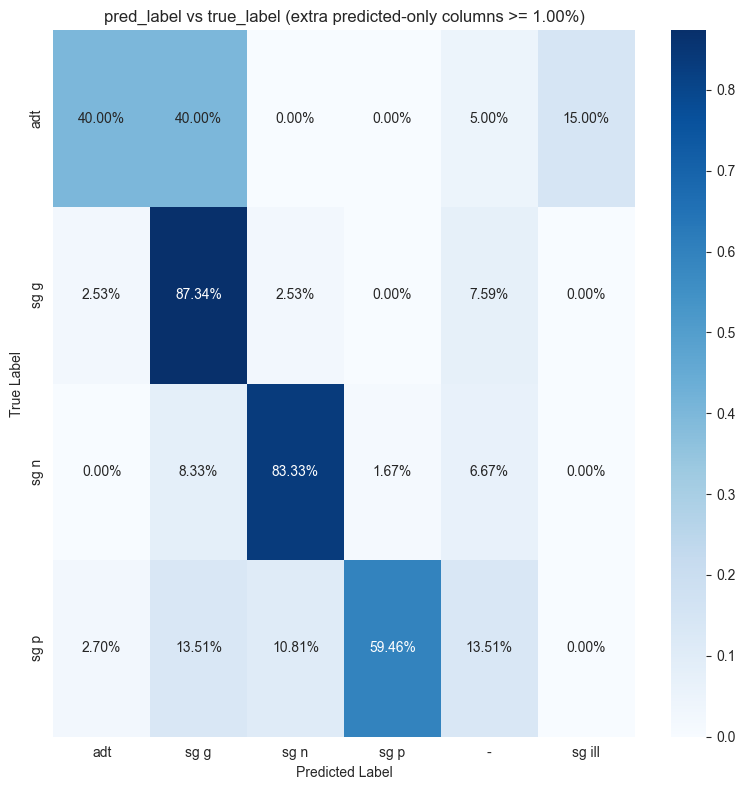

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -     16        8.0              True            1.0
1               sg ill      3        1.5              True            1.0
2                   da      1        0.5             False            1.0
3                 pl g      1        0.5             False            1.0
4                 pl n      1        0.5             False            1.0
5                 pl p      1        0.5             False            1.0
Sum of true labels count: 200
Bert Morph Tagger V2 confusion matrix for homonyms subset (200):


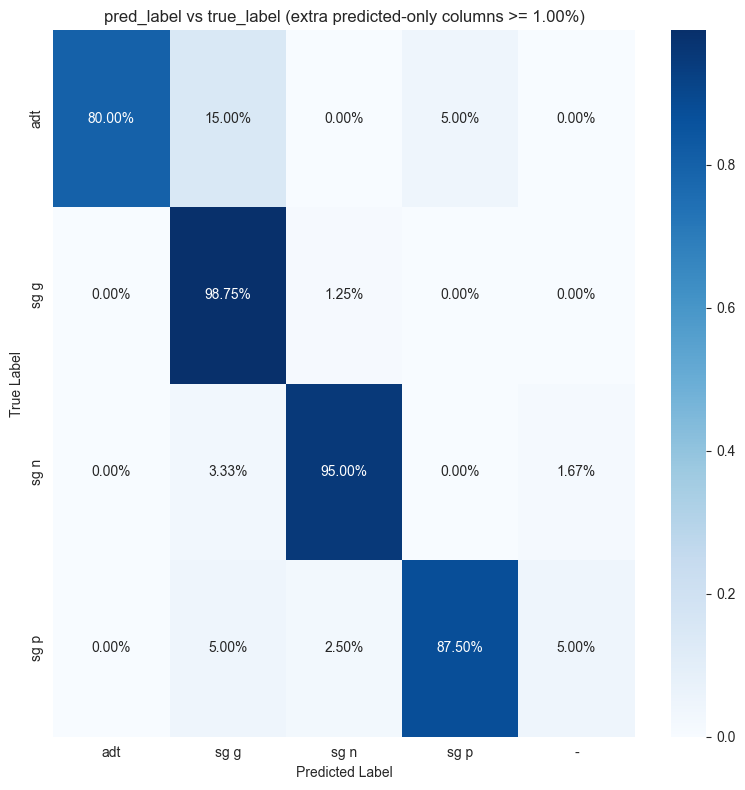

pred_label vs true_label - Predicted-only labels (not present in true labels):
  predicted_only_label  count  share_pct  included_in_plot  threshold_pct
0                    -      3        1.5              True            1.0
Sum of true labels count: 200


In [ ]:
print(f"BERT MLM-to-LLM-to-morph confusion matrix for homonyms subset ({max_rows}):")
plot_confusion_matrices(
    results_df=bert_llm_results_df, pred_col="pred_label", true_col="true_label"
)
print(f"Bert Morph Tagger V2 confusion matrix for homonyms subset ({max_rows}):")
plot_confusion_matrices(
    results_df=results_df_v2_llm_subset, pred_col="pred_label", true_col="true_label"
)

In [ ]:
# Inspect BERT MLM predictions where the model got the prediction wrong
bert_llm_results_df["correct"] = (
    bert_llm_results_df["pred_label"] == bert_llm_results_df["true_label"]
)

In [ ]:
display(bert_llm_results_df[~bert_llm_results_df["correct"]].head(20))

,id,candidates,candidate_details,predictions,pred_label,source_sentence,target_word,word_span,true_label,inflection_type,correct
6,4009,"[mingi, teatud, ühe, väikese, suure]","[{'token': 'teatud', 'score': 0.30268719792366, 'resolved_form': ['pl n', 'sg n', 'tud'], 'normalised_score': 0.496241554412897}, {'token': 'mingi', 'score': 0.199384421110153, 'resolved_form': ['sg n'], 'normalised_score': 0.32688146620053604}, {'token': 'ühe', 'score': 0.106323853135108, 'resolved_form': ['sg g'], 'normalised_score': 0.174313002045901}, {'token': 'väikese', 'score': 0.0011429892620070002, 'resolved_form': ['sg g'], 'normalised_score': 0.0018738776266270002}, {'token': 'suure', 'score': 0.00042093280353500004, 'resolved_form': ['sg g'], 'normalised_score': 0.0006900997140370001}]","{'pl n': 0.496241554412897, 'sg n': 0.32688146620053604, 'sg g': 0.17687697938656602}",pl n,"Ma rõhutan veel kord, et me ei taotle kogu müügist laekuva raha arvamist metsakapitali hulka, vaid me taotleme sellest mingi kindla osa reserveerimist uue metsa taastootmiseks ehk kasvatamiseks.",mingi,"[119, 124]",sg g,1,False
9,4506,"[Tallinna, Tartu, Pärnu, Nõmme, Narva]","[{'token': 'Tallinna', 'score': 0.8012089729309081, 'resolved_form': ['adt'], 'normalised_score': 0.9990623349087141}, {'token': 'Nõmme', 'score': 0.000362986815162, 'resolved_form': ['sg g'], 'normalised_score': 0.00045262405608100003}, {'token': 'Pärnu', 'score': 0.00028516550082700003, 'resolved_form': ['sg g'], 'normalised_score': 0.000355585272653}, {'token': 'Tartu', 'score': 7.445715164067224e-05, 'resolved_form': ['sg g'], 'normalised_score': 9.284386256517497e-05}, {'token': 'Narva', 'score': 2.9361313863773834e-05, 'resolved_form': ['adt'], 'normalised_score': 3.6611899985871823e-05}]","{'adt': 0.9990989468087, 'sg g': 0.000901053191299}",adt,Neli hooaega Soomes veetnud kaitsja sõlmis kaheaastase lepingu Eesti jalgpallimeistri Maardu FC Levadiaga ning seab uusi sihte.,Maardu,"[86, 92]",sg g,1,False
12,878,"[Aafrika, Aasia, Ameerika, Euroopa, Inglismaa]",[],{},None,"Chichester kandis esimese ehmatusega kaardile Austraalia lähema punkti Fremantlei, kuid tema lõi selja sirgeks.",Austraalia,"[46, 56]",sg g,1,False
17,884,[Kanada],[],{},None,Kanada rajasid inglastest ja prantslastest väljarändajad.,Kanada,"[0, 6]",sg g,1,False
22,4380,"[linn, vald, maakond, omavalitsus, piirkond]",[],{},None,"Lõppeva muusikasuve järel tõstatus taas teravalt vajadus kontserdi- ja konverentsisaali järele, mille rajamisel ei saa Pärnu loota ainult välistele allikatele.",Pärnu,"[119, 124]",sg n,1,False
25,560,"[JÄÄR, KAALUD, SKORPION, VEEVALAJA, KALAD]",[],{},None,"NEITSI Kui tunned, et olukorrad ahistavad su vabadusi, siis lõdvestu ja võta aeg maha.",NEITSI,"[0, 6]",sg n,16,False
35,3986,"[Jelena, Tatjana, Marina, Irina, Olga]","[{'token': 'Jelena', 'score': 0.23462878167629203, 'resolved_form': ['sg g'], 'normalised_score': 0.566570251577866}, {'token': 'Irina', 'score': 0.062754802405834, 'resolved_form': ['sg n'], 'normalised_score': 0.151537266369334}, {'token': 'Tatjana', 'score': 0.05193969979882201, 'resolved_form': ['sg g'], 'normalised_score': 0.12542147886399302}, {'token': 'Olga', 'score': 0.03299580514431, 'resolved_form': ['sg n'], 'normalised_score': 0.079676676868304}, {'token': 'Marina', 'score': 0.031802162528038004, 'resolved_form': ['sg g'], 'normalised_score': 0.07679432632050001}]","{'sg g': 0.7687860567623601, 'sg n': 0.23121394323763902}",sg g,""" Röövkallaletungi ohvriks langenud kasukakaupluse omanikeks on ärimees Abram Sheri tütar Marika ja Tulika Takso juhi Mati Saare abikaasa Galina.",Marika,"[90, 96]",sg n,16,False
45,1867,"[Venemaa, Rootsi, Soome, Läti, Leedu]","[{'token': 'Venemaa', 'score': 0.007533562369644001, 'resolved_form': ['sg n'], 'normalised_score': 0.47800150856447304}, {'token': 'Läti', 'score': 0.004358382429927, 'resolved_form': ['sg g'], 'normalised_score': 0.276537615829753}, {'token': 'Soome', 'score': 0.0023213913664220003, 'resolved_form': ['sg n'], 'normalised_

In [ ]:
# Count how many mispredictions there are per inflection type
mispredictions_by_inflection = (
    bert_llm_results_df[~bert_llm_results_df["correct"]]
    .groupby("inflection_type")
    .size()
    .reset_index(name="count")
)
print("Mispredictions by inflection type:")
print(mispredictions_by_inflection)

Mispredictions by inflection type:
   inflection_type  count
0                1      9
1               16     14
2               17     19
3               19      9


In [ ]:
filtered_df = bert_llm_results_df[~bert_llm_results_df["correct"]]

# Format printing of incorrect predictions for easier inspection
for i, (idx, row) in enumerate(filtered_df.iterrows()):
    sentence = row["source_sentence"]
    word = row["target_word"]
    candidates = row["candidates"]
    predictions = row["predictions"]
    inflection_type = row["inflection_type"]
    true_label = row["true_label"]
    pred_label = row["pred_label"]

    # Sort the predicted form distribution by probability in descending order
    # Most labels have None, so we need to handle that when sorting
    sorted_predicted_form_distribution = dict(
        sorted(
            predictions.items(),
            key=lambda item: item[1] if item[1] is not None else 0,
            reverse=True,
        )
    )
    print(f"Sentence: {sentence}")
    print(f"Word: {word}")
    print(f"Inflection type: {inflection_type}")
    print(f"True label: {true_label}, Predicted label: {pred_label}")
    print("Candidates: ")
    print("  -", end=" ")
    for c_i, candidate in enumerate(candidates):
        if c_i + 1 == len(candidates):
            print(f"{candidate}")
        else:
            print(f"{candidate},", end=" ")
    print("Predicted form distribution (sorted): ")
    for label, prob in sorted_predicted_form_distribution.items():
        if prob is not None:
            print(f"  - {label}: {prob}")
    print("-" * 50)
    if i >= 20:  # Limit to first 20 incorrect predictions for inspection
        break

Sentence: Ma rõhutan veel kord, et me ei taotle kogu müügist laekuva raha arvamist metsakapitali hulka, vaid me taotleme sellest mingi kindla osa reserveerimist uue metsa taastootmiseks ehk kasvatamiseks.
Word: mingi
Inflection type: 1
True label: sg g, Predicted label: pl n
Candidates: 
  - mingi, teatud, ühe, väikese, suure
Predicted form distribution (sorted): 
  - pl n: 0.496241554412897
  - sg n: 0.32688146620053604
  - sg g: 0.17687697938656602
--------------------------------------------------
Sentence: Neli hooaega Soomes veetnud kaitsja sõlmis kaheaastase lepingu Eesti jalgpallimeistri Maardu FC Levadiaga ning seab uusi sihte.
Word: Maardu
Inflection type: 1
True label: sg g, Predicted label: adt
Candidates: 
  - Tallinna, Tartu, Pärnu, Nõmme, Narva
Predicted form distribution (sorted): 
  - adt: 0.9990989468087
  - sg g: 0.000901053191299
--------------------------------------------------
Sentence: Chichester kandis esimese ehmatusega kaardile Austraalia lähema punkti Fremant